# Upbit Basic Chart

티커, 시작 날짜, 끝 날짜, 분봉 간격을 입력하면 업비트 OHLCV 데이터를 가져와 캔들 차트와 거래량을 표시합니다.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pandas as pd
import pyupbit

ROOT_DIR = Path.cwd().resolve().parent if Path.cwd().name == 'backtesting' else Path.cwd().resolve()
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

plt.style.use('ggplot')
pd.set_option('display.max_rows', 10)


In [2]:
TICKER = 'KRW-BTC'
START_DATE = '2026-05-01 00:00:00'
END_DATE = '2026-05-08 00:00:00'
INTERVAL = 'minute60'
REQUEST_COUNT = 200


def interval_to_timedelta(interval: str) -> pd.Timedelta:
    if interval.startswith('minute'):
        return pd.Timedelta(minutes=int(interval.replace('minute', '')))
    if interval == 'day':
        return pd.Timedelta(days=1)
    if interval == 'week':
        return pd.Timedelta(weeks=1)
    raise ValueError(f'Unsupported interval: {interval}')


def fetch_ohlcv_range(
    ticker: str,
    start_date: str,
    end_date: str,
    interval: str = 'minute60',
    request_count: int = 200,
) -> pd.DataFrame:
    start_ts = pd.Timestamp(start_date)
    end_ts = pd.Timestamp(end_date)
    if start_ts > end_ts:
        raise ValueError('START_DATE must be earlier than or equal to END_DATE.')

    step = interval_to_timedelta(interval)
    cursor = end_ts + step
    frames: list[pd.DataFrame] = []

    while True:
        df = pyupbit.get_ohlcv(
            ticker,
            interval=interval,
            count=request_count,
            to=cursor.strftime('%Y-%m-%d %H:%M:%S'),
        )
        if df is None or df.empty:
            break

        df = df.sort_index()
        frames.append(df)

        oldest = df.index.min()
        if oldest <= start_ts or len(df) < request_count:
            break

        cursor = oldest

    if not frames:
        raise ValueError(f'No OHLCV data returned for {ticker} ({interval}).')

    merged = pd.concat(frames).sort_index()
    merged = merged[~merged.index.duplicated(keep='last')]
    filtered = merged.loc[(merged.index >= start_ts) & (merged.index <= end_ts)].copy()

    if filtered.empty:
        raise ValueError('No candles found in the selected date range.')

    return filtered


def plot_candles(df: pd.DataFrame, ticker: str, interval: str) -> None:
    chart_df = df.reset_index().rename(columns={'index': 'datetime'})
    x = mdates.date2num(chart_df['datetime'].dt.to_pydatetime())
    candle_width = max(0.0005, (x[1] - x[0]) * 0.7) if len(x) > 1 else 0.02

    fig, (ax_price, ax_volume) = plt.subplots(
        2,
        1,
        figsize=(16, 9),
        sharex=True,
        gridspec_kw={'height_ratios': [3, 1]},
    )

    for i, row in chart_df.iterrows():
        color = '#d62728' if row['close'] >= row['open'] else '#1f77b4'
        ax_price.vlines(x[i], row['low'], row['high'], color=color, linewidth=1.0)
        body_bottom = min(row['open'], row['close'])
        body_height = abs(row['close'] - row['open'])
        if body_height == 0:
            body_height = max(row['close'] * 0.0005, 1e-6)
        ax_price.add_patch(
            Rectangle(
                (x[i] - candle_width / 2, body_bottom),
                candle_width,
                body_height,
                facecolor=color,
                edgecolor=color,
                alpha=0.85,
            )
        )
        ax_volume.bar(x[i], row['volume'], width=candle_width, color=color, alpha=0.35)

    ax_price.set_title(f'{ticker} {interval} Candle Chart')
    ax_price.set_ylabel('Price (KRW)')
    ax_volume.set_ylabel('Volume')
    ax_volume.set_xlabel('Datetime')
    ax_price.grid(True, alpha=0.3)
    ax_volume.grid(True, alpha=0.2)

    locator = mdates.AutoDateLocator()
    formatter = mdates.ConciseDateFormatter(locator)
    ax_volume.xaxis.set_major_locator(locator)
    ax_volume.xaxis.set_major_formatter(formatter)

    plt.tight_layout()
    plt.show()


,open,high,low,close,volume,value
2026-05-07 20:00:00,118858000.0,119141000.0,118800000.0,118841000.0,38.794900,4.614021e+09
2026-05-07 21:00:00,118870000.0,119193000.0,118837000.0,119138000.0,40.791206,4.855186e+09
2026-05-07 22:00:00,119139000.0,119155000.0,118200000.0,118552000.0,128.489332,1.523449e+10
2026-05-07 23:00:00,118525000.0,118620000.0,118000000.0,118048000.0,111.968604,1.323868e+10
2026-05-08 00:00:00,118050000.0,118196000.0,117580000.0,117763000.0,138.533816,1.633073e+10


/var/folders/d9/xb3pxm293r15sx57hh9pcrh80000gn/T/ipykernel_4794/206736276.py:68: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  x = mdates.date2num(chart_df['datetime'].dt.to_pydatetime())


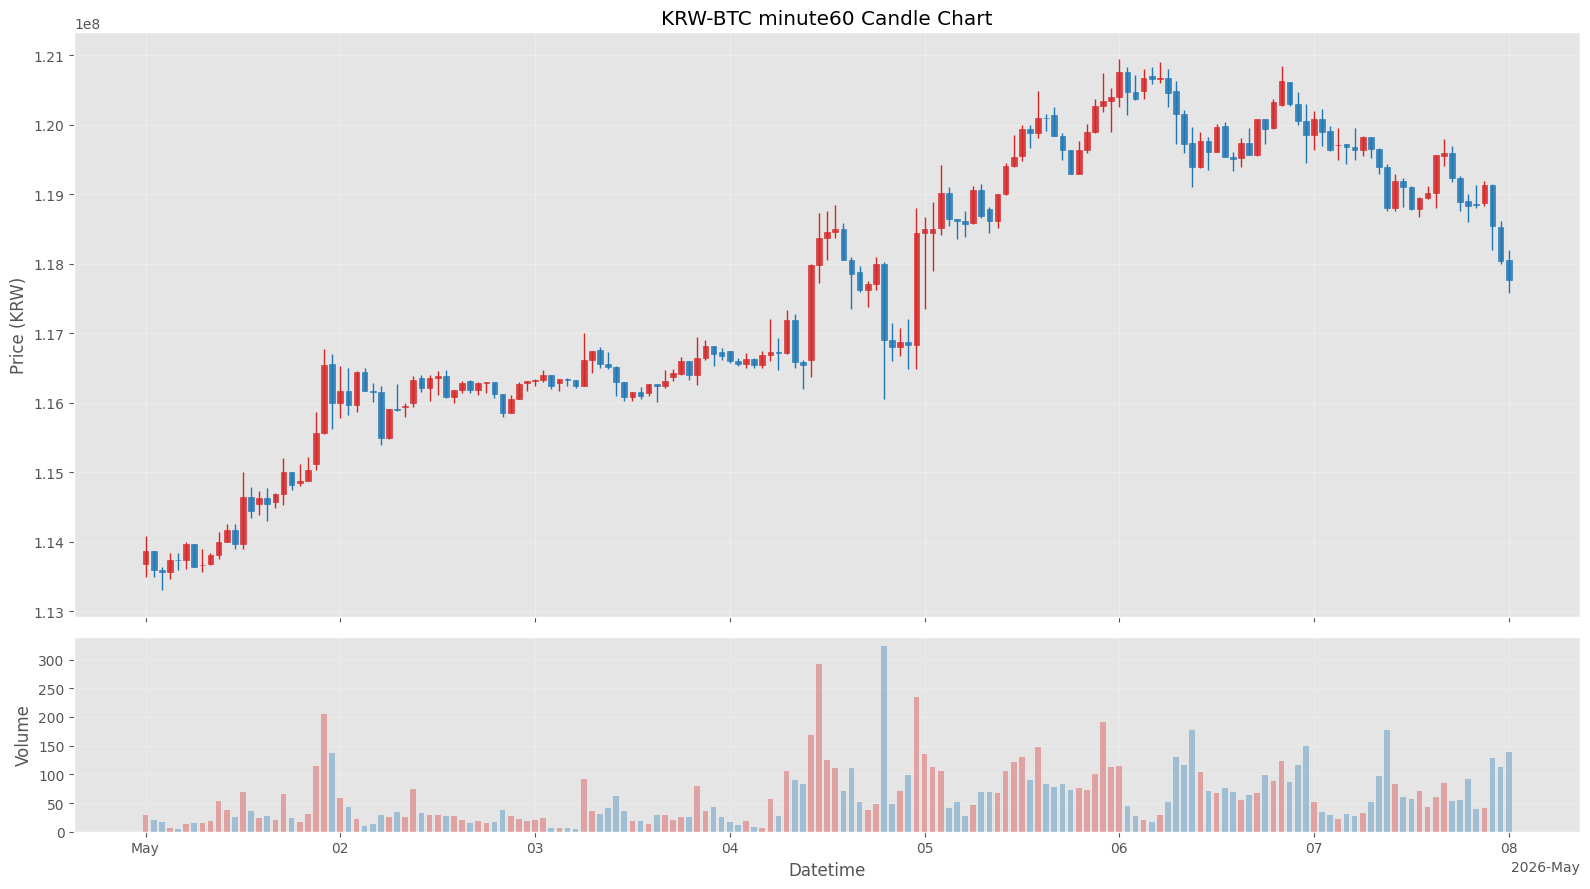

In [3]:
ohlcv_df = fetch_ohlcv_range(
    ticker=TICKER,
    start_date=START_DATE,
    end_date=END_DATE,
    interval=INTERVAL,
    request_count=REQUEST_COUNT,
)

display(ohlcv_df.tail())
plot_candles(ohlcv_df, ticker=TICKER, interval=INTERVAL)
